# FES Acatlán, UNAM
## Módulo 3. Diplomado introducción a la Ciencia de Datos
### Oscar Gutiérrez Leal


# ENSAFI 2023 – Visualización

Este notebook carga los datos obtenidos en la Parte A directamente desde archivos CSV alojados en el repositorio público del proyecto en GitHub.  
Esto permite la ejecución del notebook desde Google Colab sin requerir descargas manuales.

A partir de estos datos se construyen las visualizaciones solicitadas, siguiendo los lineamientos y criterios establecidos en la rúbrica del curso.


## 1. Carga de los CSV


In [1]:
# importar librerias para manejo dataframe y gráficos

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
# carga de consulta1_privaciones desde el repositorio
url1 = "https://raw.githubusercontent.com/ockis2403/ensafi2023/main/datos_procesados/consulta1_privaciones.csv"
pd.options.display.html.use_mathjax = False
consulta1 = pd.read_csv(url1)
consulta1

,rango_id,rango_descripcion,hog_privaciones,tot_hogares,prop_privacion,prop_no_privacion
0,1,"Hasta $3,600",3377,4020,0.840050,0.159950
1,2,"De $3,601 a $6,100",3541,4440,0.797523,0.202477
2,3,"De $6,101 a $8,100",1949,2639,0.738537,0.261463
3,4,"De $8,101 a $9,900",847,1238,0.684168,0.315832
4,5,"De $9,901 a $12,100",1491,2432,0.613076,0.386924
5,6,"De $12,101 a $14,500",582,1008,0.577381,0.422619
6,7,"De $14,501 a $17,600",632,1268,0.498423,0.501577
7,8,"De $17,601 a $21,900",463,1201,0.385512,0.614488
8,9,"De $21,901 a $29,100",291,903,0.322259,0.677741
9,10,"De $29,101 a $45,100",192,857,0.224037,0.775963


In [3]:
# carga de consulta2_estres
url2 = "https://raw.githubusercontent.com/ockis2403/ensafi2023/main/datos_procesados/consulta2_estres.csv"
pd.options.display.html.use_mathjax = False
consulta2 = pd.read_csv(url2)
consulta2

,rango_id,rango_descripcion,flag_privacion,promedio_emociones_acum
0,1,"Hasta $3,600",con privacion,1.815517
1,2,"De $3,601 a $6,100",con privacion,1.794973
2,3,"De $6,101 a $8,100",con privacion,1.741406
3,4,"De $8,101 a $9,900",con privacion,1.691854
4,5,"De $9,901 a $12,100",con privacion,1.666667
5,6,"De $12,101 a $14,500",con privacion,1.757732
6,7,"De $14,501 a $17,600",con privacion,1.653481
7,8,"De $17,601 a $21,900",con privacion,1.598272
8,9,"De $21,901 a $29,100",con privacion,1.639175
9,10,"De $29,101 a $45,100",con privacion,1.531250


## 2. Visualizaciones

Las visualizaciones se elaboraron siguiendo los criterios establecidos en la rúbrica del curso, cuidando tanto la claridad narrativa como la calidad técnica de la salida gráfica.  

En la construcción del lienzo se utilizó una resolución de `dpi = 150`, adecuada para la visualización en pantalla. Para la exportación final de las imágenes se empleó una resolución de `dpi = 300`, con el objetivo de garantizar calidad de impresión.


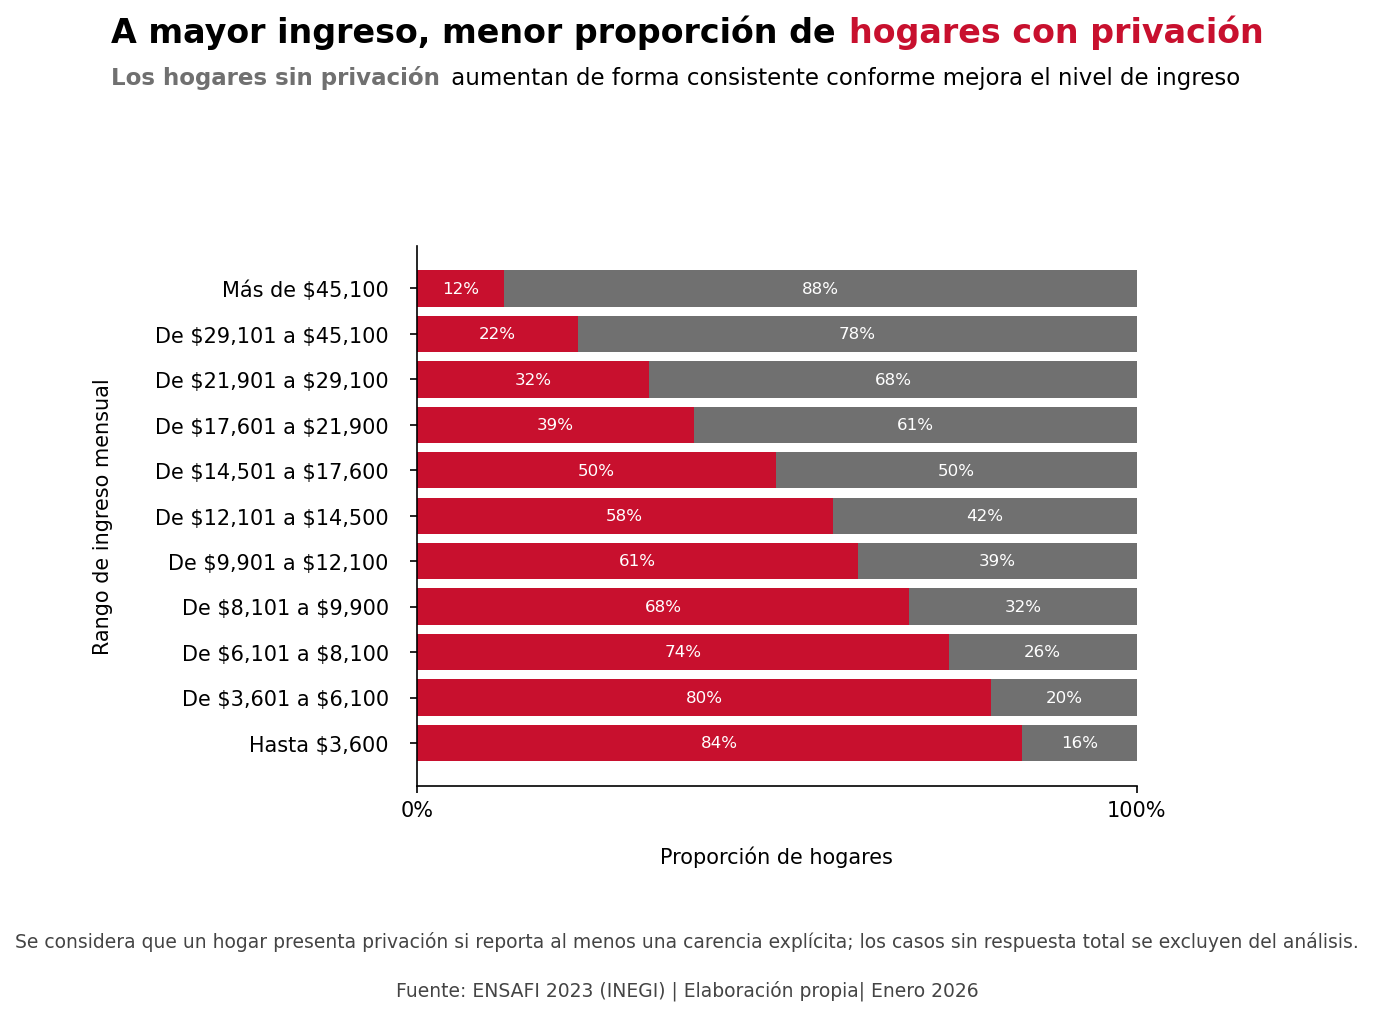

In [4]:
# GRáfica de barras horizontales apiladas 100%

# Preparación de etiquetas del rango de ingresos
consulta1["rango_plot"] = consulta1["rango_descripcion"].str.replace(
    "$", r"\$", regex=False)

# se definen los Colores para cada atributo
color_privacion = "#C8102E"
color_no_privacion = "#707070"

# Lienzo
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_axes([0.35, 0.30, 0.40, 0.45])

# barras apiladas horizontales

ax.barh(
    consulta1["rango_plot"],
    consulta1["prop_privacion"],
    color=color_privacion
)

ax.barh(
    consulta1["rango_plot"],
    consulta1["prop_no_privacion"],
    left=consulta1["prop_privacion"],
    color=color_no_privacion
)


# Titulo y subtitulo con leyenda
fig.text(0.18, 0.92,"A mayor ingreso, menor proporción de ",
         fontsize=16,fontweight="bold")
fig.text(0.59, 0.92,"hogares con privación",
         fontsize=16,fontweight="bold",color=color_privacion)
fig.text(0.18, 0.885, "Los hogares sin privación",fontsize=11,fontweight="bold",color=color_no_privacion
)
fig.text(0.365, 0.885," aumentan de forma consistente conforme mejora el nivel de ingreso",
         fontsize=11)


# formato
ax.set_xlim(0, 1)
ax.set_xticks([0,1.0])
ax.set_xticklabels(["0%","100%"])
ax.tick_params(axis="y", pad=10)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Etiquetas dentro de gráfico
for i, row in consulta1.iterrows():
#privación
    ax.text(
        row["prop_privacion"] / 2,
        i,
        f"{row['prop_privacion']*100:.0f}%",
        va="center",
        ha="center",
        fontsize=8,
        color="white"
    )

# No privación
    ax.text(
        row["prop_privacion"] + row["prop_no_privacion"] / 2,
        i,
        f"{row['prop_no_privacion']*100:.0f}%",
        va="center",
        ha="center",
        fontsize=8,
        color="white"
    )

#titulos de ejes
ax.set_xlabel("Proporción de hogares", labelpad=12)
ax.set_ylabel("Rango de ingreso mensual", labelpad=20)


# Instructivo
fig.text(
    0.5, 0.17,
    "Se considera que un hogar presenta privación si reporta al menos una carencia explícita; "
    "los casos sin respuesta total se excluyen del análisis.",
    ha="center",
    va="center",
    fontsize=9,
    color="#444444"
)

# fuente y autoria
fig.text(
    0.5, 0.13,
    "Fuente: ENSAFI 2023 (INEGI) | Elaboración propia| Enero 2026",
    ha="center",
    va="center",
    fontsize=9,
    color="#444444"
)

#descarga y grafico mostrado
plt.savefig("consulta1_privaciones.png", dpi=300, bbox_inches='tight')
plt.show()


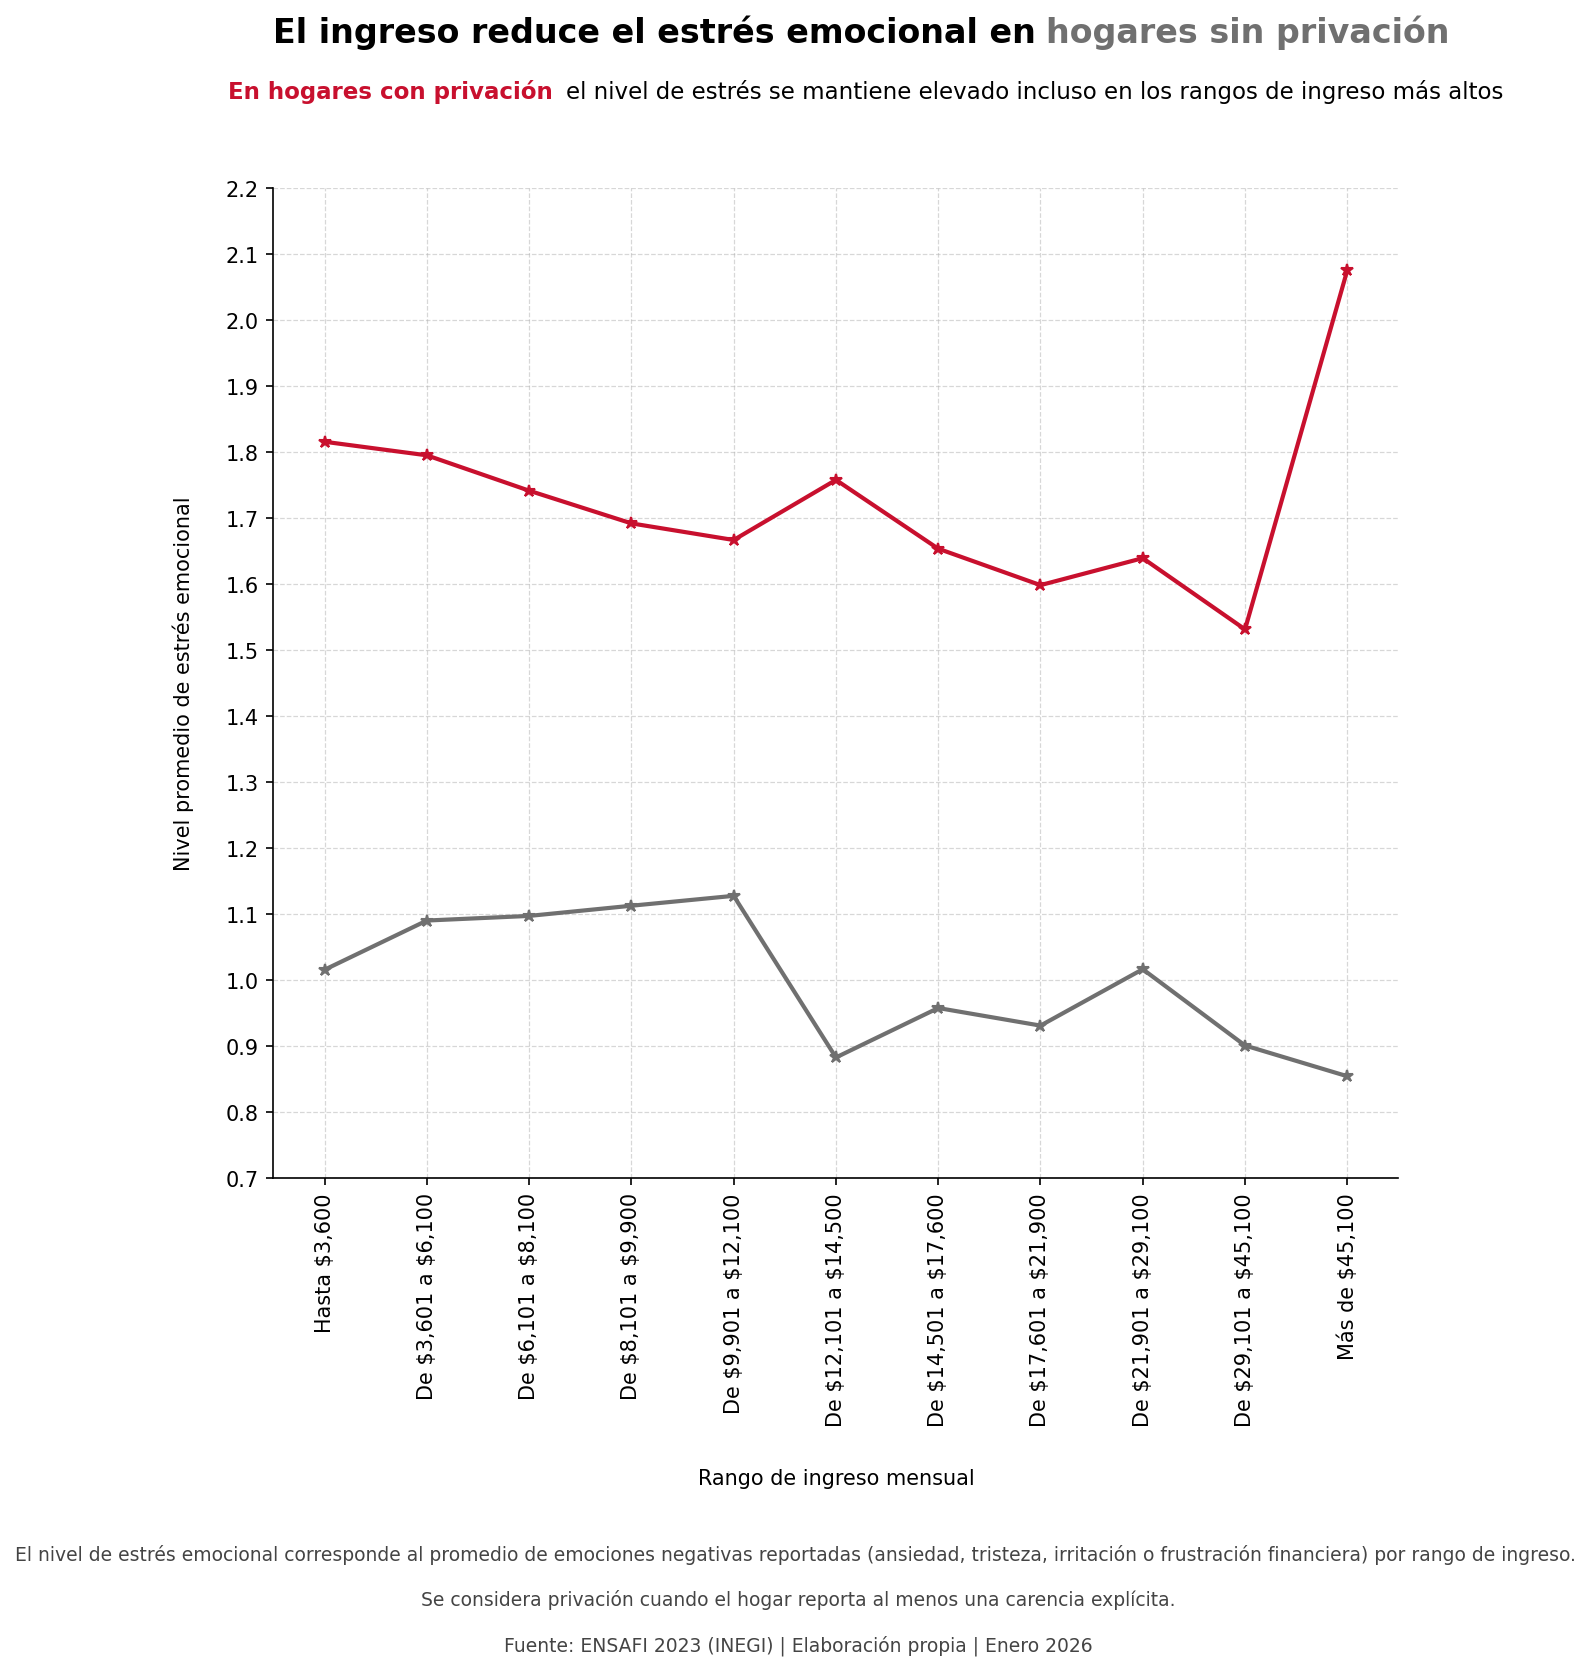

In [5]:
# Grafico de lineas múltiples

# Preparación de etiquetas del rango de ingresos
consulta2["rango_plot"] = consulta2["rango_descripcion"].str.replace(
    "$", r"\$", regex=False)

# Colores
color_privacion = "#C8102E"
color_no_privacion = "#707070"

# Ordenar rangos por id
consulta2 = consulta2.sort_values("rango_id")

# Separar grupos
df_priv = consulta2[consulta2["flag_privacion"] == "con privacion"]
df_no_priv = consulta2[consulta2["flag_privacion"] == "sin privacion"]

# Lienzo vertical para  énfasis en eje Y)
fig = plt.figure(figsize=(10, 15), dpi=150)

# Área del gráfico
ax = fig.add_axes([0.15, 0.37, 0.75, 0.44])

# Líneas
ax.plot(
    df_priv["rango_plot"],
    df_priv["promedio_emociones_acum"],
    color=color_privacion,
    marker="*",
    linewidth=2,
    label="Hogares con privación"
)

ax.plot(
    df_no_priv["rango_plot"],
    df_no_priv["promedio_emociones_acum"],
    color=color_no_privacion,
    marker="*",
    linewidth=2,
    label="Hogares sin privación"
)

# Eje Y con formato preciso en las marcas
ax.set_ylim(0.7, 2.2)
ax.set_yticks(np.arange(0.7, 2.21, 0.1))
ax.set_ylabel("Nivel promedio de estrés emocional", labelpad=15)

# Eje X
ax.set_xlabel("Rango de ingreso mensual", labelpad=20)
ax.tick_params(axis="x", rotation=90)

# Grid suave con lineas y transparencias discretas
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

# Quitar bordes para limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# titulo y subtitulo cuidando la ubicación y la función narrativa
fig.text(0.15, 0.875, "El ingreso reduce el estrés emocional en ",fontsize=16, fontweight="bold")
fig.text(0.665, 0.875, "hogares sin privación",fontsize=16, fontweight="bold", color=color_no_privacion)

fig.text(0.12, 0.85,"En hogares con privación", fontsize=11, fontweight="bold", color=color_privacion)
fig.text(0.345, 0.85, "el nivel de estrés se mantiene elevado incluso en los rangos de ingreso más altos",         
   fontsize=11)

#instructivo
fig.text(
    0.5, 0.20,
    "El nivel de estrés emocional corresponde al promedio de emociones negativas reportadas "
    "(ansiedad, tristeza, irritación o frustración financiera) por rango de ingreso. ",
    ha="center",
    fontsize=9,
    color="#444444"
)
fig.text(
    0.5, 0.18,
    "Se considera privación cuando el hogar reporta al menos una carencia explícita.",
    ha="center",
    fontsize=9,
    color="#444444"
)

#fuente, autor y fecha
fig.text(
    0.5, 0.16,
    "Fuente: ENSAFI 2023 (INEGI) | Elaboración propia | Enero 2026",
    ha="center",
    fontsize=9,
    color="#444444"
)

#descarga y grafico mostrado
plt.savefig("consulta2_estres.png", dpi=300, bbox_inches='tight')
plt.show()


#### Autor: Oscar Gutiérrez Leal
#### Diplomado: Introducción a la Ciencia de Datos
#### Fuente de Datos: Encuesta Nacional sobre Salud Financiera (ENSAFI) 2023. INEGI
#### Fecha de última actualización: Enero 2026
#### Repositorio: https://github.com/ockis2403/ensafi2023
